In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

## Basic EDA

### Load data from csv

In [32]:
df=pd.read_csv("VisaData.csv")

In [33]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [34]:
df.shape

(25480, 12)

In [35]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [37]:
numerical_features = df.select_dtypes(include='number').columns.tolist()
numerical_features

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

In [38]:
categorical_features = df.select_dtypes(include=['category', 'object']).columns.tolist()
categorical_features

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [39]:
for col in categorical_features:

    print(df[col].value_counts())
    print("---------------------------------------------------------------------")

case_id
EZYV01       1
EZYV16995    1
EZYV16993    1
EZYV16992    1
EZYV16991    1
            ..
EZYV8492     1
EZYV8491     1
EZYV8490     1
EZYV8489     1
EZYV25480    1
Name: count, Length: 25480, dtype: int64
---------------------------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
---------------------------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
---------------------------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
---------------------------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
---------------------------------------------------------------

### Insights

- `case_id` has unique values for each row, which can be dropped as it is of no importance.
- `continent` column is highly biased towards Asia. Hence, we can combine other categories into a single category.
- `unit_of_wage` seems to be an important column, as most of them are yearly contracts.

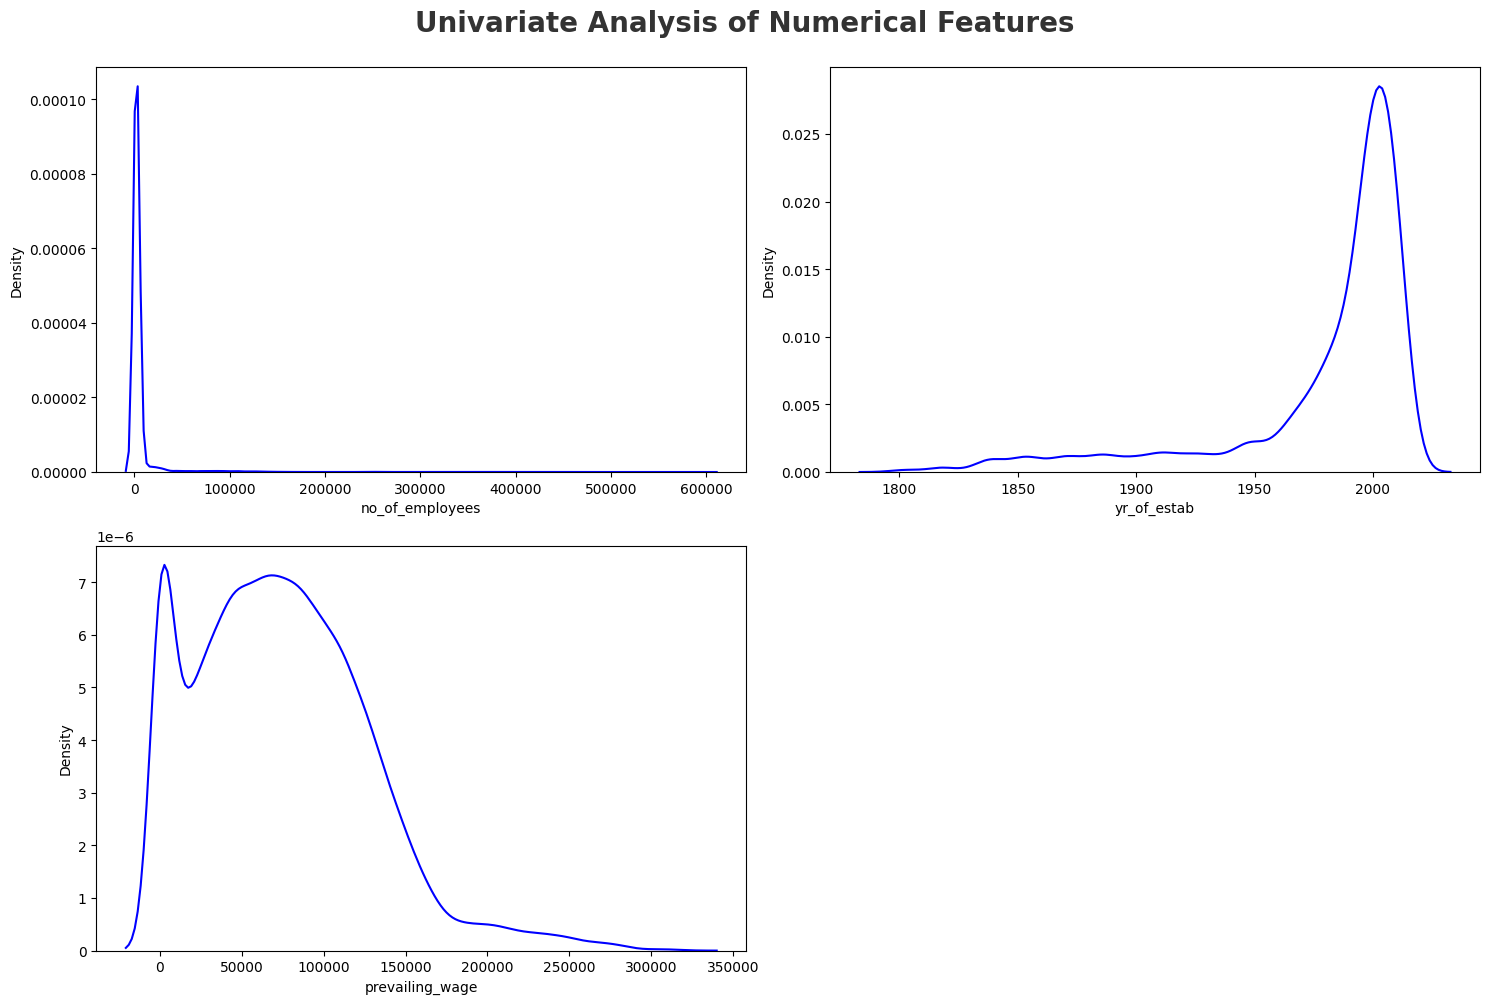

In [40]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numerical_features)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df[numerical_features[i]], color='blue')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()



### Insights

- `no_of_employees` column looks more skewed, but it may be because of outliers.
- `yr_of_estab` is a discrete feature.
- `prevailing_wage` is a right-skewed distribution.

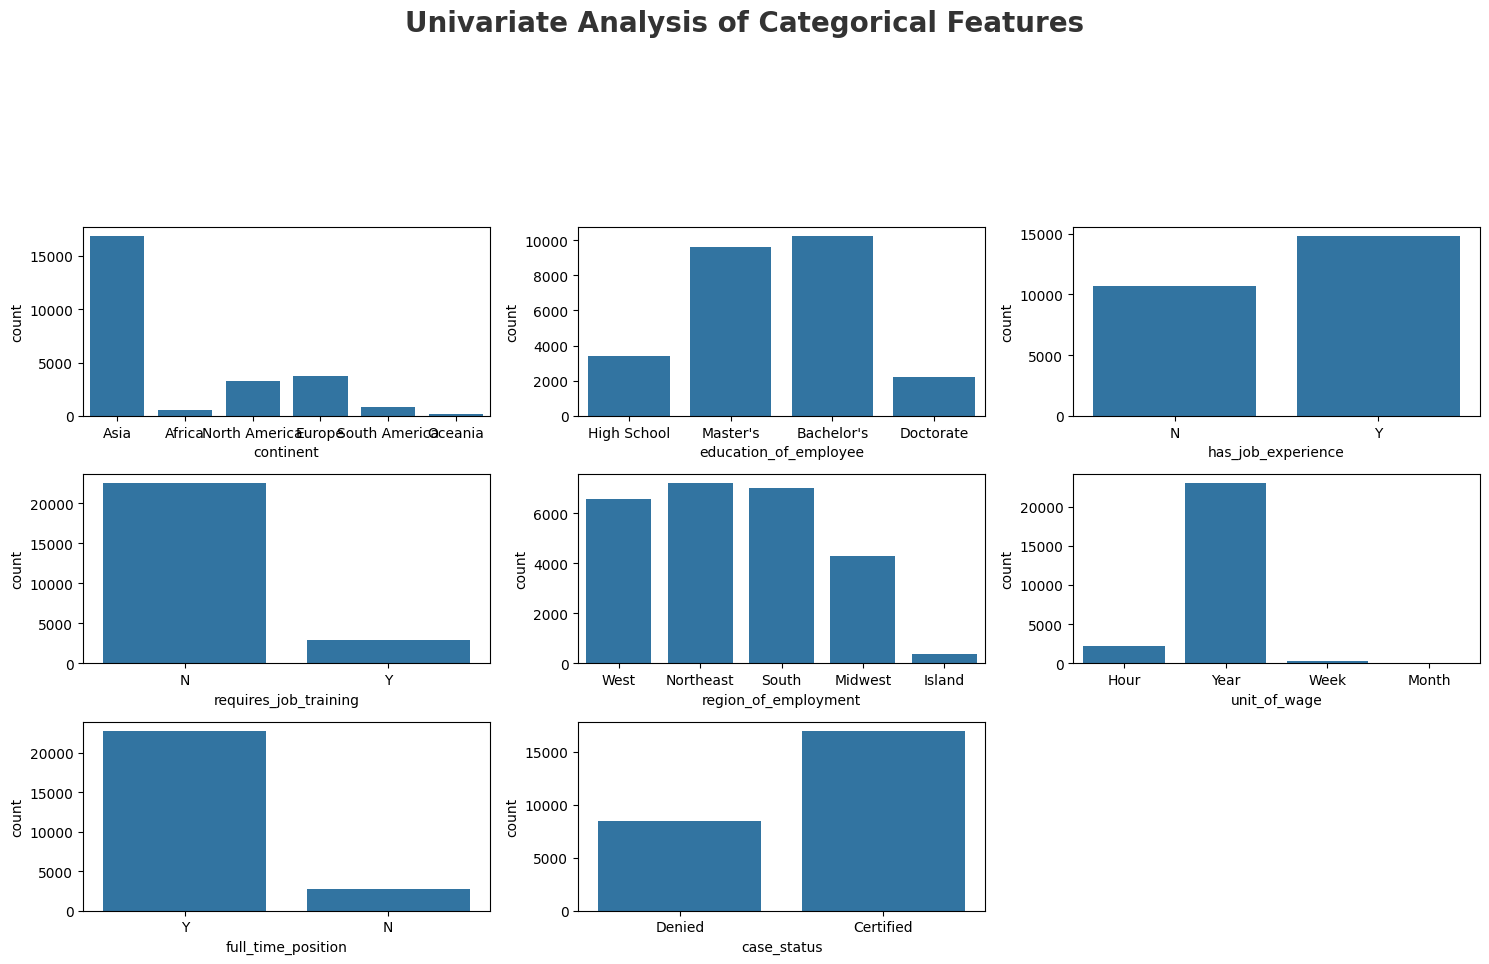

In [42]:
# categorical columns
categorical_features.remove('case_id')
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.2)

for i in range(0, len(categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

# save plot
# plt.savefig('./images/Univariate_Cat.png')


### Insights

- `requires_job_training`, `unit_of_wage`, `full_time_position`, and `continent` columns have a single category dominating.
- The rest of the columns are balanced.

In [44]:
discrete_features = [feature for feature in numerical_features if len(df[feature].unique()) <= 25]
continuous_features = [feature for feature in numerical_features if len(df[feature].unique()) > 25]

print('We have {} discrete features: {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous features: {}'.format(len(continuous_features), continuous_features))

We have 0 discrete features: []

We have 3 continuous features: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


### Check Multicollinearity for Categorical Features

A chi-squared test (also chi-square or χ² test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis — specifically, Pearson's chi-square test.

A chi-square statistic is one way to show a relationship between two categorical variables.

Here, we test the correlation of categorical columns with the target column, i.e., `case_status`.

- **Null Hypothesis (H0):** The feature is independent of the target column (no correlation).
- **Alternative Hypothesis (H1):** The feature and target column are not independent (correlated).

In [45]:
from scipy.stats import chi2_contingency

chi2_test = []

for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')

result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result

,Column,Hypothesis Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


### Report

Here, `requires_job_training` fails to reject the null hypothesis, which means it does not correlate with the target column.

In [48]:
df.case_status.value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

It is an imbalanced dataset

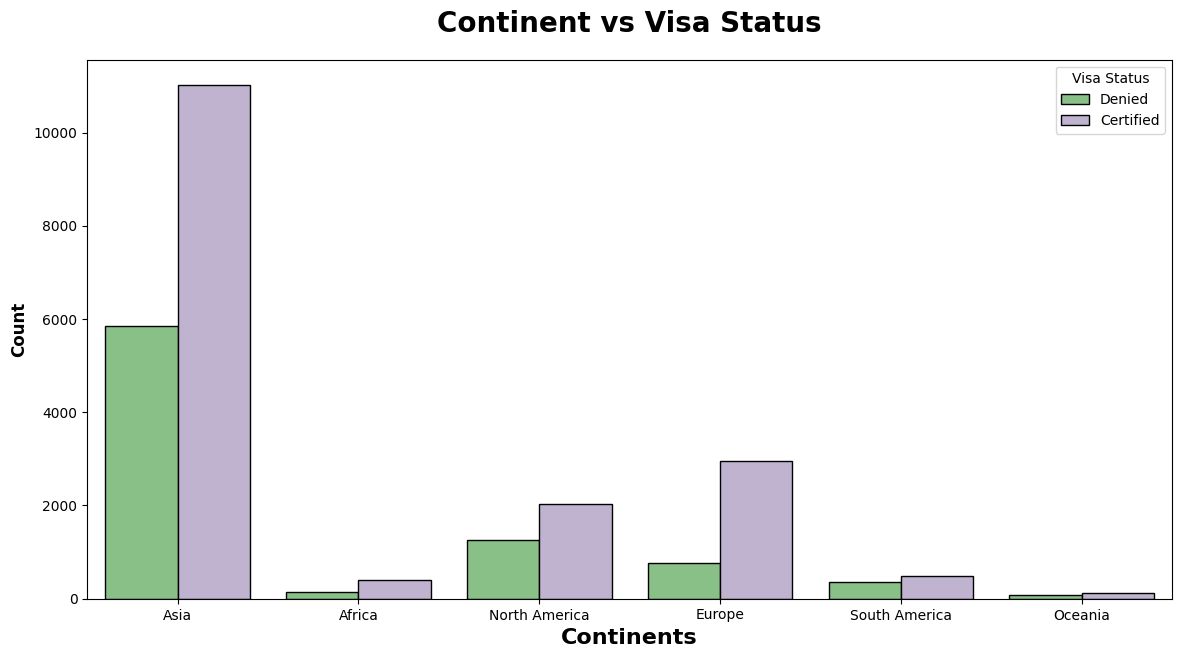

In [50]:

# Set up the figure size
plt.subplots(figsize=(14, 7))

# Create a grouped count plot
sns.countplot(x="continent", hue="case_status", data=df, ec="black", palette="Accent")

# Add a bold title with padding
plt.title("Continent vs Visa Status", weight="bold", fontsize=20, pad=20)

# Label the y-axis
plt.ylabel("Count", weight="bold", fontsize=12)

# Label the x-axis
plt.xlabel("Continents", weight="bold", fontsize=16)

# Customize the legend with a title and rounded box edges
plt.legend(title="Visa Status", fancybox=True)

# Display the chart
plt.show()


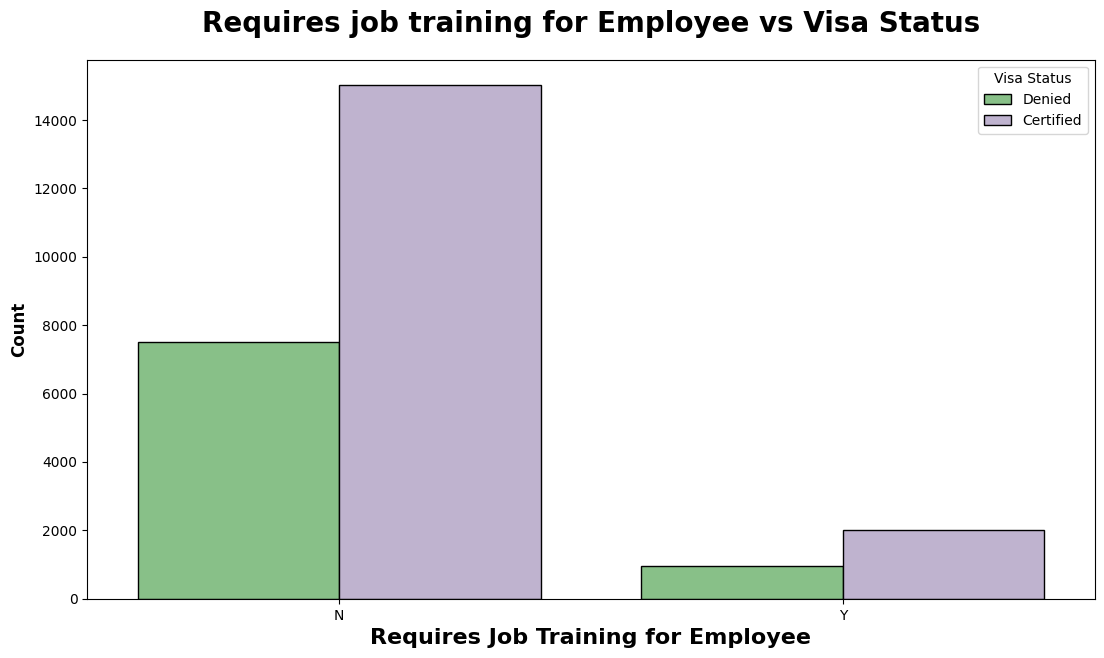

In [52]:
plt.subplots(figsize=(13,7))
sns.countplot(x="requires_job_training", hue="case_status", data=df, ec= "black", palette="Accent")
plt.title("Requires job training for Employee vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()


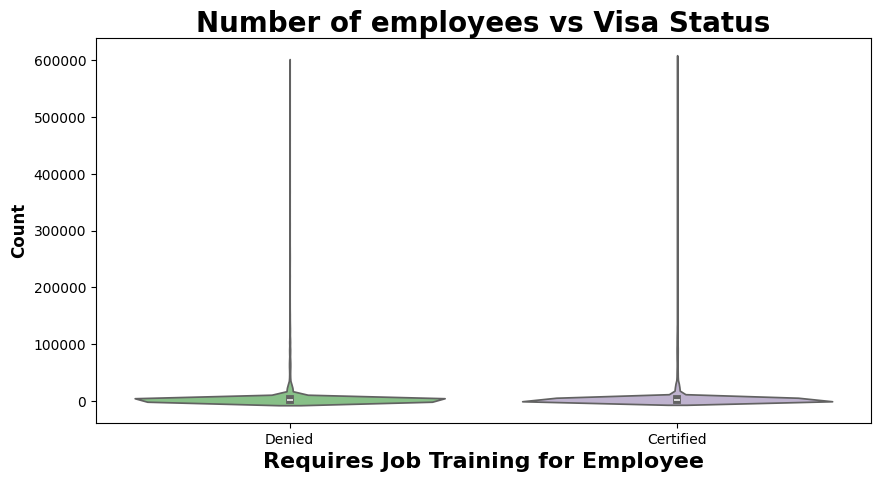

In [56]:
plt.subplots (figsize=(10,5))
sns.violinplot(x="case_status", y='no_of_employees', data=df, palette="Accent")
plt.title("Number of employees vs Visa Status", weight="bold", fontsize=20, pad=2)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.ylim()
plt.show()

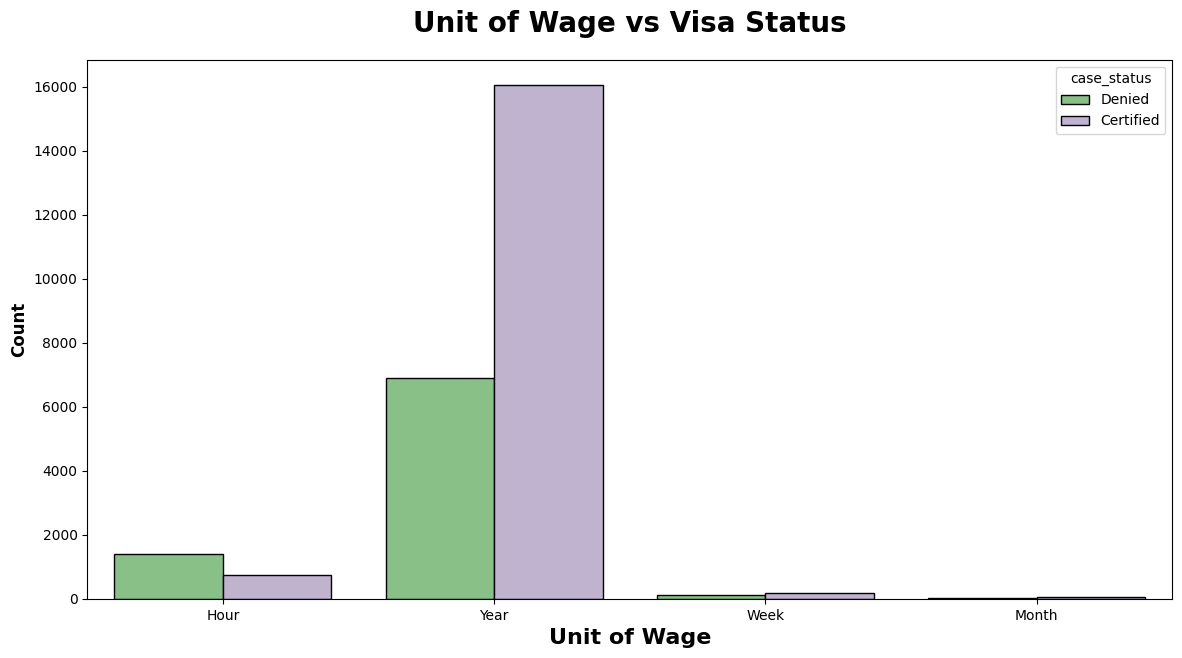

In [57]:
plt.subplots(figsize=(14, 7))
sns.countplot(x="unit_of_wage", hue="case_status", data=df, ec='k', palette='Accent')
plt.title("Unit of Wage vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("Unit of Wage", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

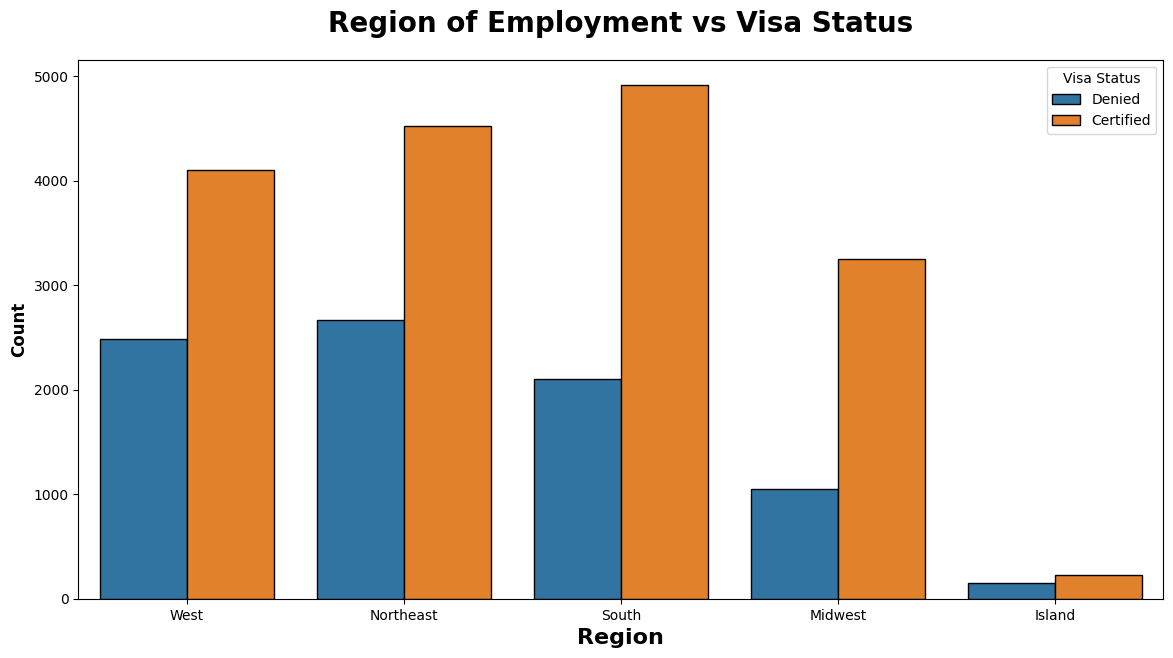

In [58]:
plt.subplots (figsize=(14,7))
sns.countplot(x="region_of_employment", hue="case_status", data=df, ec='k')
plt.title("Region of Employment vs Visa Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.legend(title="Visa Status", fancybox=True)
plt.show()